# Complete Library Showcase

This notebook provide an exhaustive demonstration of **Matrix Generation, Sparsification, Hybrid Fusion, and Node Batching** using the **PEMS-BAY** traffic dataset.


## 1. Setup and Imports


In [10]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.data.loaders import load_dataset
from src.matrix_generation import (
    PearsonCorrelationGenerator, PartialCorrelationGenerator, DTWGenerator, 
    GrangerCausalityGenerator, MutualInformationGenerator, EmbeddingCosineGenerator
)
from src.sparcification import (
    MatrixConstructionPipeline, TopKRowSparsifier, MutualKNNSparsifier, 
    MSTSparsifier, PMFGSparsifier, RowL1Normalizer
)
from src.hybrid import SNFDiffusionFuser, WeightedAverageFuser
from src.batching import (
    KHopBatcher, GreedyClusterBatcher, LouvainBatcher, SpectralBatcher, 
    BalancedPartitionBatcher, OverlappingBatcher, DegreeAwareBatcher
)
from src.utils.visualization import (
    plot_adjacency_matrix_heatmap, compare_adjacency_matrices_heatmap,
    plot_matrix_spy, plot_node_neighborhood, plot_node_time_series
)
from src.utils.graph_metrics import calculate_graph_metrics

print("Imports successful!")


Imports successful!


## 2. Dataset Loading
Loading PEMS-BAY (50 nodes).


In [20]:
dataset_root = '../data/PEMS-BAY/'
data_dict = load_dataset(dataset_root, load_adj_matrix=False, verbose=False)
data = np.array(data_dict['data'][:1000,:, :])
print(f"Working data shape: {data.shape}")


Attempting to load data with shape [52116, 325, 3]...
Data loaded successfully as a numpy.memmap object.
Data shape: (52116, 325, 3)
Working data shape: (1000, 325, 3)


## 3. Full Pipeline: Generation -> Fusion -> Sparsification


In [ ]:
# 1. Generate Multiple Perspectives
m1 = PearsonCorrelationGenerator().generate(data)
m2 = MutualInformationGenerator(n_neighbors=3).generate(data)
print('aaa')

# 2. Hybrid Fusion (SNF)
fused = SNFDiffusionFuser(k_neighbors=5, n_iterations=10).fuse([m1, m2])

# 3. Structural Sparsification (MST + TopK)
adj = MatrixConstructionPipeline(
    sparsifiers=[TopKRowSparsifier(k_per_node=3)]
).run(fused, k=150)

plot_matrix_spy(adj, title="Final Adjacency Sparsity Pattern")


aaa


KeyboardInterrupt: 

## 4. Comprehensive Node Batching
We demonstrate the 7 primary batching algorithms on the generated graph.


In [17]:
# Initialize all batchers
batchers = [
    ("K-Hop (k=1)", KHopBatcher(k=1, max_batch_size=16)),
    ("Greedy", GreedyClusterBatcher(max_batch_size=16)),
    ("Louvain", LouvainBatcher()),
    ("Spectral", SpectralBatcher(n_clusters=4)),
    ("Balanced", BalancedPartitionBatcher(n_clusters=4)),
    ("Overlapping", OverlappingBatcher(seed_fraction=0.3)),
    ("Degree-Aware", DegreeAwareBatcher(base_size=10))
]

results = []
for name, b in batchers:
    batches = b.batch(adj)
    results.append({
        "Method": name,
        "Num Batches": len(batches),
        "Avg Size": np.mean([len(x) for x in batches]),
        "Max Size": np.max([len(x) for x in batches]),
        "Min Size": np.min([len(x) for x in batches])
    })

import pandas as pd
display(pd.DataFrame(results))


,Method,Num Batches,Avg Size,Max Size,Min Size
0,K-Hop (k=1),35,1.428571,5,1
1,Greedy,36,1.388889,7,1
2,Louvain,3,16.666667,30,3
3,Spectral,4,12.500000,28,5
4,Balanced,4,12.500000,13,11
5,Overlapping,15,12.066667,31,5
6,Degree-Aware,44,1.136364,4,1


## 5. Visualizing a Batch Neighborhood
Selecting a batch from Louvain Clustering and visualizing its local structure.


Visualizing batch with nodes: [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 20, 22, 24, 26, 31, 32, 33, 35, 37, 38, 39, 41, 42, 43, 46, 48, 49]


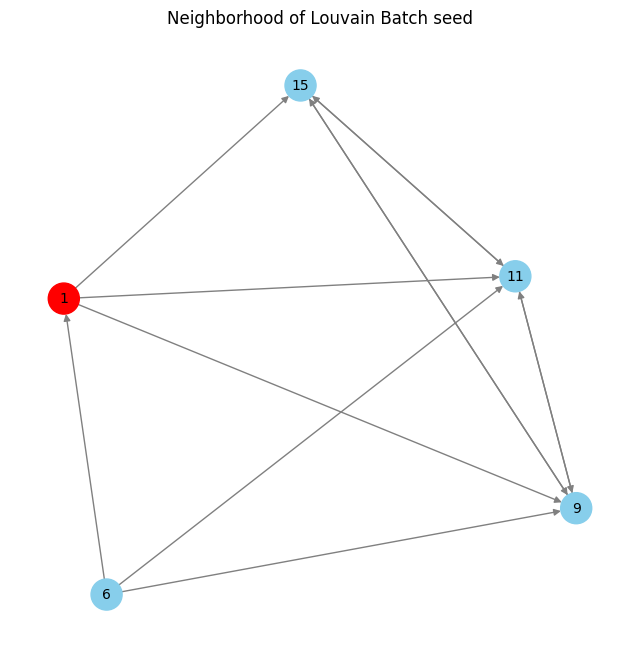

In [18]:
louvain_batches = LouvainBatcher().batch(adj)
target_batch = louvain_batches[0]
print(f"Visualizing batch with nodes: {target_batch}")

plot_node_neighborhood(adj, node_idx=target_batch[0], title="Neighborhood of Louvain Batch seed")


## 6. Metrics Report


In [19]:
m = calculate_graph_metrics(adj, directed=True)
for k, v in m.items():
    print(f"{k:25}: {v}")


num_nodes                : 50
total_edges              : 150
density                  : 0.061224489795918366
sparsity                 : 0.94
avg_connection_strength  : 0.020236238837242126
clustering_coefficient   : 0.00040816326530612246
algebraic_connectivity   : 1.2202264754179737e-09
spectral_gap             : 0.0009497366845607758
num_components           : 42
is_connected             : True
min_degree               : 3
max_degree               : 33
mean_degree              : 6.0
median_degree            : 3.0
mode_degree              : 3
std_degree               : 6.942621983083913
q1_degree                : 3.0
q3_degree                : 4.0
reciprocity              : 0.08666666666666667
mean_in_degree           : 3.0
mean_out_degree          : 3.0
